# 01 – LiDAR Processing & Structural Metrics

Reproduces Section 3.2.3 and Section 4.1 of the report:
- Load and height-normalise the UAV point cloud
- Compute 23 structural metrics per 20 m pixel (Table 2)
- Write a multiband GeoTIFF used by all downstream notebooks

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # repo root
from src import config
from src.lidar_metrics import (
    load_and_normalise,
    compute_structural_metrics_raster,
    get_bbox_lonlat,
    METRIC_NAMES,
)
import rasterio
import numpy as np
import matplotlib.pyplot as plt

## 1.1 Set the path to your .las file
Edit `config.LAS_FILE` in `src/config.py`, or override here:

In [2]:
# Override if needed, e.g.:
# config.LAS_FILE = pathlib.Path(r"C:\data\beetaloo_sample.las")

print("LAS file:", config.LAS_FILE)
print("Outputs will go to:", config.OUTPUT_DIR)

LAS file: C:\Users\whusg\beetaloo_project\data\TurnerRiver2024-C1-AHD_6597715_50.laz
Outputs will go to: C:\Users\whusg\beetaloo_project\outputs


## 1.2 Load and height-normalise

In [3]:
x, y, z_norm, classification, crs = load_and_normalise(config.LAS_FILE)
print(f"Loaded {len(x):,} points")
print(f"Spatial extent: X [{x.min():.1f}, {x.max():.1f}]  Y [{y.min():.1f}, {y.max():.1f}]")
print(f"Height range (after filtering): {z_norm.min():.2f} – {z_norm.max():.2f} m")
print(f"CRS: {crs}")

Loaded 44,988,264 points
Spatial extent: X [659000.0, 660000.0]  Y [7715000.0, 7716000.0]
Height range (after filtering): 0.00 – 14.85 m
CRS: PROJCS["GDA2020 / GDA2020 / MGA 50S",GEOGCS["GDA2020",DATUM["Geocentric_Datum_of_Australia_2020",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","9844"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.01745329251994328,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","7844"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","7850"]]


## 1.3 Height distribution (quick QC)

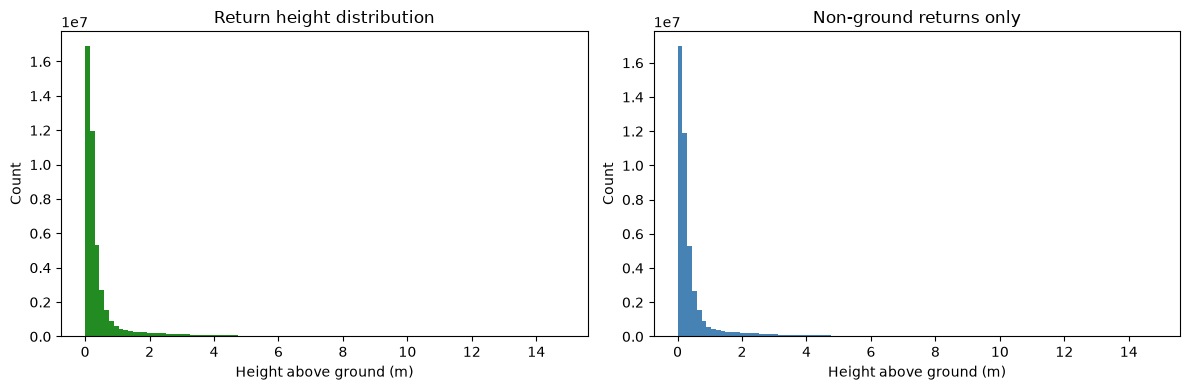

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(z_norm, bins=100, color='forestgreen', edgecolor='none')
axes[0].set(xlabel='Height above ground (m)', ylabel='Count', title='Return height distribution')

axes[1].hist(z_norm[z_norm > 0], bins=100, color='steelblue', edgecolor='none')
axes[1].set(xlabel='Height above ground (m)', ylabel='Count', title='Non-ground returns only')

plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'qc_height_distribution.png', dpi=150)
plt.show()

## 1.4 Compute 23 structural metrics → 20 m raster

In [5]:
out_path, transform = compute_structural_metrics_raster(x, y, z_norm, crs)
print(f"Written: {out_path}")
print(f"Metrics: {METRIC_NAMES}")

Written: C:\Users\whusg\beetaloo_project\outputs\lidar_structural_metrics.tif
Metrics: ['GFP', 'PAI', 'stdev', 'p5', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'p98', 'dens_0_1m', 'dens_1_2m', 'dens_2_3m', 'dens_3_4m', 'dens_4_5m', 'dens_5_10m', 'dens_10_15m', 'dens_15_20m', 'dens_20_25m', 'dens_>1m', 'dens_>2m', 'dens_total']


## 1.5 Quick-look: GFP, PAI, stdev, p50

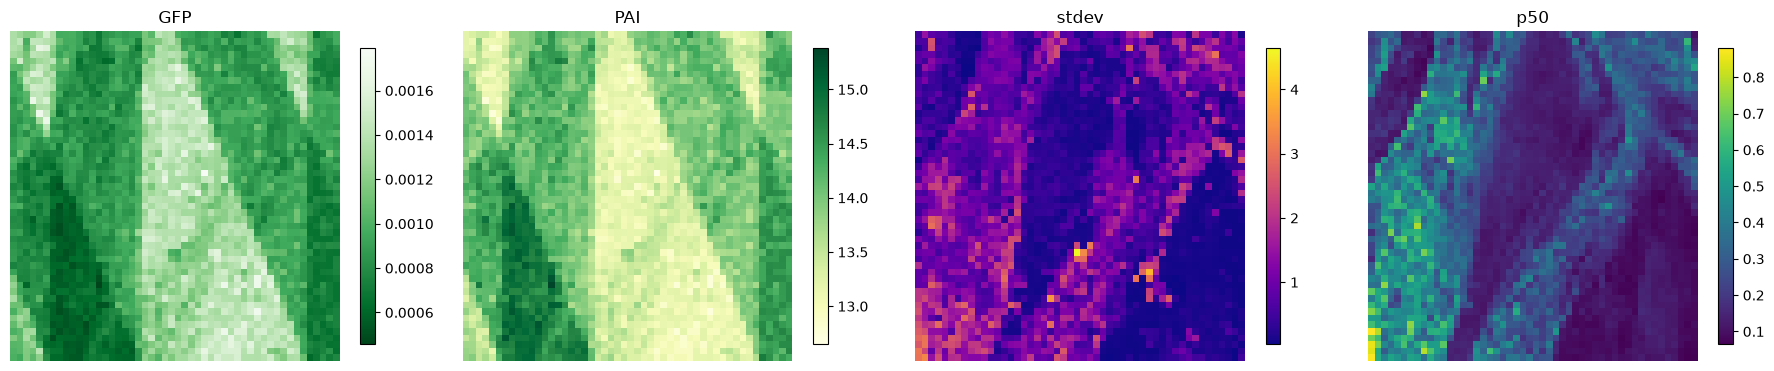

In [6]:
with rasterio.open(out_path) as src:
    descriptions = [src.descriptions[i] for i in range(src.count)]
    profile = src.profile

show_metrics = ['GFP', 'PAI', 'stdev', 'p50']
indices = [descriptions.index(m) + 1 for m in show_metrics]

with rasterio.open(out_path) as src:
    data = {m: src.read(i) for m, i in zip(show_metrics, indices)}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
cmaps = ['Greens_r', 'YlGn', 'plasma', 'viridis']
for ax, (m, cmap) in zip(axes, zip(show_metrics, cmaps)):
    arr = data[m]
    arr = np.where(arr == -9999, np.nan, arr)
    im = ax.imshow(arr, cmap=cmap, origin='upper')
    ax.set_title(m)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.axis('off')
plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'qc_structural_metrics.png', dpi=150)
plt.show()

## 1.6 Save bbox for downstream notebooks

In [7]:
import json

bbox = get_bbox_lonlat(x, y, crs)
print(f"Bounding box (EPSG:4326): {bbox}")

bbox_path = config.OUTPUT_DIR / 'bbox_lonlat.json'
with open(bbox_path, 'w') as f:
    json.dump({'minlon': bbox[0], 'minlat': bbox[1], 'maxlon': bbox[2], 'maxlat': bbox[3]}, f, indent=2)
print(f"Saved to {bbox_path}")

Bounding box (EPSG:4326): (118.52630272428725, -20.657588290191065, 118.53580876094986, -20.648470372929953)
Saved to C:\Users\whusg\beetaloo_project\outputs\bbox_lonlat.json
